In [1]:
from neuroposelib import read, preprocess, vis, write, features
import numpy as np
import time
from IPython.display import Video
from pathlib import Path
import matplotlib.pyplot as plt
from neuroposelib import DataStruct as ds
from neuroposelib.embed import Embed, Watershed
import pickle
import pywt
%matplotlib inline

analysis_key = "tutorial"
config = read.config("../configs/" + analysis_key + ".yaml")
pose, ids = read.pose_h5("/mnt/home/jwu10/working/neuroposelib/tutorials/demo_mouse/demo_mouse.h5")
connectivity = read.connectivity_config(path=config["skeleton_path"])
meta, meta_by_frame = read.meta("/mnt/home/jwu10/working/neuroposelib/tutorials/demo_mouse/demo_meta.csv", ids=ids)

Path(config["out_path"]).mkdir(parents=True, exist_ok=True)

pose_aligned = preprocess.align_floor_by_id(pose=pose, ids=ids, foot_id=12, head_id=0)
pose = preprocess.rotate_spine(preprocess.center_spine(pose_aligned, keypt_idx=4), vector=(4, 3))

ego_pose, labels = features.get_ego_pose(pose, connectivity.joint_names)

pc_feats, pc_labels = features.pca(
    ego_pose, labels, categories=["ego_euc"], n_pcs=5, method="fbpca"
)

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

Fitting and rotating the floor for each video to alignment ... 


 50%|█████     | 1/2 [00:00<00:00,  4.05it/s]

Fitting and rotating the floor for each video to alignment ... 


100%|██████████| 2/2 [00:00<00:00,  4.24it/s]


Centering poses to mid spine ...
Rotating spine to xz plane ... 
Reformatting pose to egocentric pose features ... 
Calculating principal components ... 


100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


In [2]:
from typing import Optional, Union, List, Tuple, Type
from scipy.signal import morlet2, cwt
from tqdm import tqdm

def wavelet(
    features: np.ndarray,
    labels: List[str],
    ids: Union[np.ndarray, List],
    f_s: int = 90,
    freq: Union[List, np.ndarray] = np.geomspace(1, 25, 25),
    bw: float = 1.0,
):

    print("Calculating wavelets ... ")
    # widths = (w0 * f_s / (2 * freq * np.pi)).astype(features.dtype)
    wlet_feats = np.zeros(
        (features.shape[0], len(freq) * features.shape[1]), features.dtype
    )

    wlet_labels = [
        "_".join(["wlet", label, str(np.round(f, 2))]) for f in freq for label in labels
    ]

    for i in np.unique(ids):
        print("Calculating wavelets for video " + str(i))
        wlets_i_f, freqs =pywt.cwt(
                features[ids == i],
                scales=pywt.frequency2scale("cmor{:.1f}-{:.1f}".format(bw, 1.0), freq)
                * f_s,
                wavelet="cmor{:.1f}-{:.1f}".format(bw, 1.0),
                sampling_period=1 / f_s,
                method="fft",
                axis=0,
            )
        wlets_i_f = np.abs(wlets_i_f)
        print(freqs)
        # print(wlets_i_f.shape)

        wlet_feats[ids == i] = np.swapaxes(wlets_i_f.T, 0, 1).reshape(
            wlets_i_f.shape[1], -1
        )

    return wlet_feats, wlet_labels

Continuous wavelet will be evaluated over the range [-8.0, 8.0]


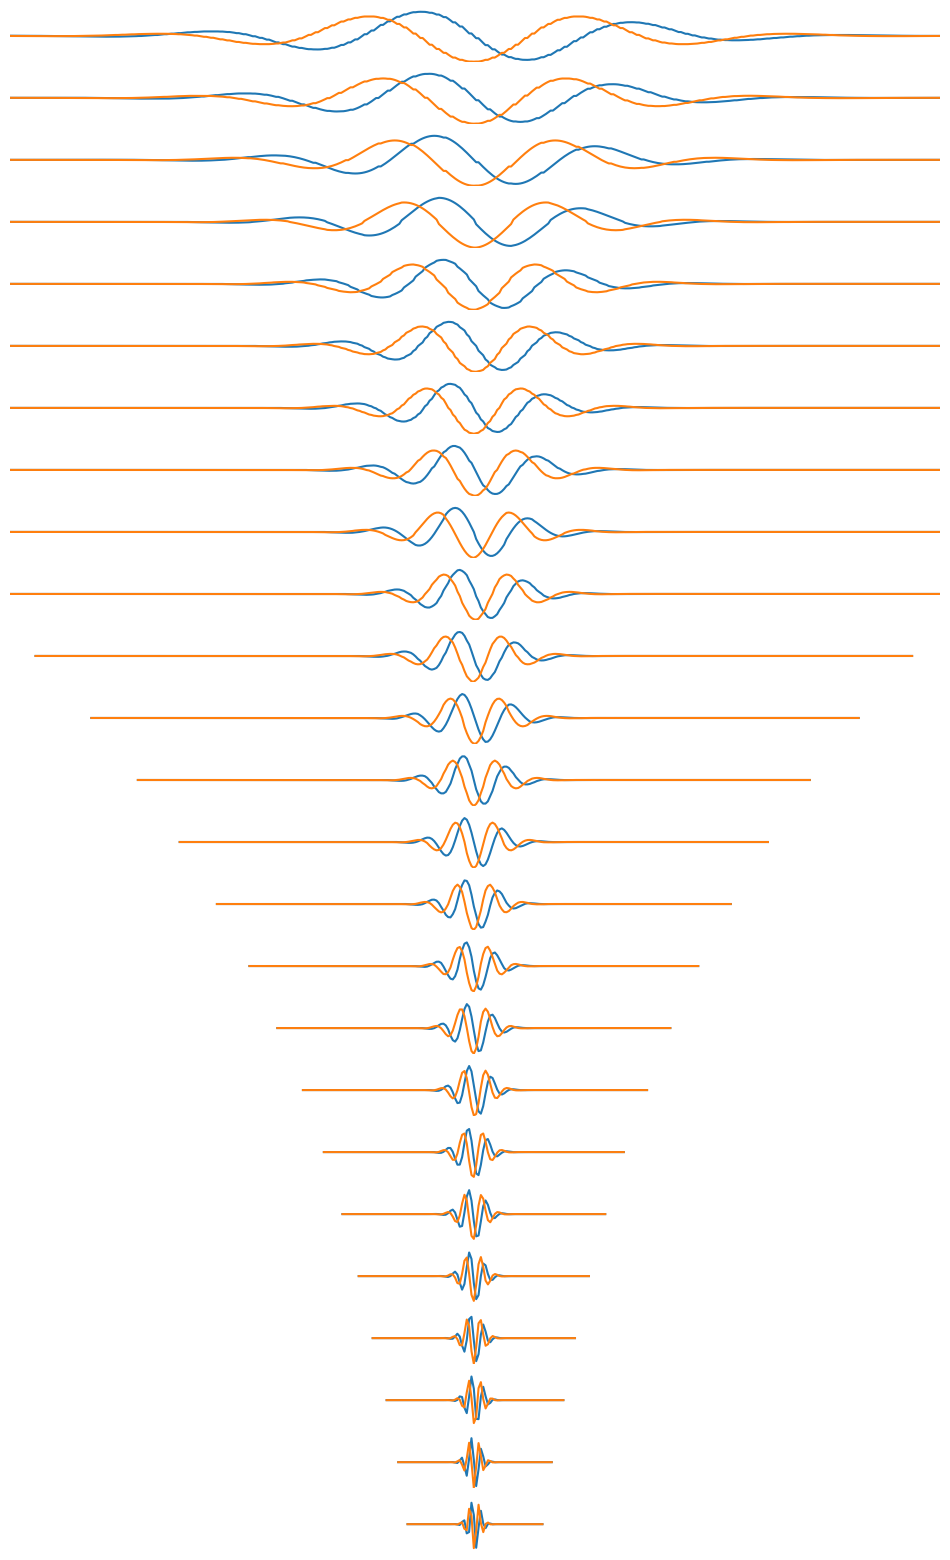

In [5]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

wav = pywt.ContinuousWavelet('cmor1.0-1.0')
# (wav.upper_bound, wav.lower_bound) = (4,-4)
# print the range over which the wavelet will be evaluated
print("Continuous wavelet will be evaluated over the range "
      f"[{wav.lower_bound}, {wav.upper_bound}]")

width = wav.upper_bound - wav.lower_bound

scales = pywt.frequency2scale('cmor1.0-1.0', np.geomspace(1,25,25))* 90

max_len = int(np.max(scales)*width + 1)
t = np.arange(max_len)
fig, axes = plt.subplots(len(scales), 1, figsize=(12, 20))
for n, scale in enumerate(scales):

    # The following code is adapted from the internals of cwt
    int_psi, x = pywt.integrate_wavelet(wav, precision=10)
    step = x[1] - x[0]
    j = np.floor(
        np.arange(scale * width + 1) / (scale * step))
    if np.max(j) >= np.size(int_psi):
        j = np.delete(j, np.where(j >= np.size(int_psi))[0])
    j = j.astype(np.int_)

    # normalize int_psi for easier plotting
    int_psi /= np.abs(int_psi).max()

    # discrete samples of the integrated wavelet
    filt = int_psi[j][::-1]

    # The CWT consists of convolution of filt with the signal at this scale
    # Here we plot this discrete convolution kernel at each scale.

    nt = len(filt)
    t = np.linspace(-nt//2, nt//2, nt)
    axes[n].plot(t, filt.real, t, filt.imag)
    axes[n].set_xlim([-200, 200])
    axes[n].set_ylim([-1, 1])
    # axes[n].text(50, 0.35, f'scale = {scale}')
    axes[n].axis("off")

plt.savefig("./wlets.svg",dpi=400)
plt.show()

Calculating wavelets ... 
Calculating wavelets for video 0
[ 1.          1.14352984  1.30766049  1.49534878  1.70997595  1.95540851
  2.23606798  2.55701045  2.92401774  3.34370152  3.82362246  4.37242636
  5.          5.71764918  6.53830243  7.47674391  8.54987973  9.77704257
 11.18033989 12.78505224 14.62008869 16.71850762 19.11811228 21.86213181
 25.        ]
Calculating wavelets for video 1
[ 1.          1.14352984  1.30766049  1.49534878  1.70997595  1.95540851
  2.23606798  2.55701045  2.92401774  3.34370152  3.82362246  4.37242636
  5.          5.71764918  6.53830243  7.47674391  8.54987973  9.77704257
 11.18033989 12.78505224 14.62008869 16.71850762 19.11811228 21.86213181
 25.        ]
['wlet_ego_euc_pc0_1.0', 'wlet_ego_euc_pc1_1.0', 'wlet_ego_euc_pc2_1.0', 'wlet_ego_euc_pc3_1.0', 'wlet_ego_euc_pc4_1.0', 'wlet_ego_euc_pc0_1.14', 'wlet_ego_euc_pc1_1.14', 'wlet_ego_euc_pc2_1.14', 'wlet_ego_euc_pc3_1.14', 'wlet_ego_euc_pc4_1.14', 'wlet_ego_euc_pc0_1.31', 'wlet_ego_euc_pc1_1.31', 

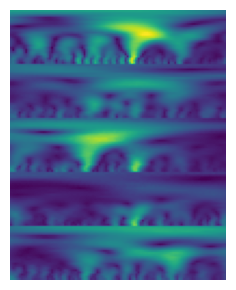

In [ ]:
wlet_feats, wlet_labels = wavelet(
    pc_feats, pc_labels, ids, f_s=90, freq=np.geomspace(1, 25, 25), bw=0.5
)
wlet_feats = (wlet_feats - wlet_feats.mean(axis=0)) / wlet_feats.std(axis=0)
print(wlet_labels)
ind = 6080
import matplotlib.pyplot as plt

f = plt.figure(figsize=(5, 3))
plt.imshow(wlet_feats[ind : ind + 100 : 1, :].T)
plt.ylabel("Wavelet Features")
plt.xlabel("Time (Frame)")
plt.axis("off")
f.tight_layout()
plt.savefig("./spectrogram.svg")
plt.show()

In [ ]:
vis.pose.arena3D(pose_aligned,
                 )